# 05 Solar hosting capacity

*APPLY*

**Question:** How much solar can this feeder take under one limit?

- Declare one overvoltage ceiling (`1.05 pu`) for the IEEE 13-node feeder and inspect the resulting PV bracket at bus 675.
- Run the CEPT sweep, inspect solver-backed results, and verify the exact run.
- The result is criterion- and model-specific; it is not utility approval, thermal/protection acceptance, or project validation.


## ⚙ Setup — Initialize the teaching environment

Run the setup cell once to load helpers and check runtime dependencies.


In [1]:
#@title 1. Setup — run once
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "7707385fd5fe60a9bec2e0bdd1bda33bc7b06bab71a8304dff0a7de86d23a0c6":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0


Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## 🧩 Inputs — Declare one hosting criterion

Set one criterion for this demonstrator: the overvoltage ceiling \(V_{\max}=1.05\ \mathrm{pu}\).


In [2]:
#@title 2. Inputs — hosting-capacity demonstrator
RUN_DIR = WORKSPACE / "runs" / "03-hosting-capacity"
V_MAX_PU = 1.05
DIRECT_SIZES_KW = (0, 1000, 2000)
table(
    ["declared input", "value", "unit"],
    [
        ("network", "IEEE 13-node feeder", "text"),
        ("PV bus", "675", "bus"),
        ("criterion", "overvoltage", "text"),
        ("voltage ceiling", V_MAX_PU, "pu"),
    ],
)

declared input   value                unit
---------------  -------------------  ----
network          IEEE 13-node feeder  text
PV bus           675                  bus
criterion        overvoltage          text
voltage ceiling  1.05                 pu


## ▶ Run — Sweep PV size

Run `cept run --demo hosting-capacity --network ieee13`; CEPT increases PV injection through OpenDSS against the declared criterion.


In [3]:
# 3. Run study — same CEPT CLI as a normal terminal
!cept run --demo hosting-capacity \
    --network ieee13 \
    --out runs/03-hosting-capacity \
    --force \
    --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the hosting-capacity search and saved the evidence
Saved run          runs\03-hosting-capacity
Case fingerprint   849d2148e0b1 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\03-hosting-capacity --format text


## 🔎 Explore — Inspect feeder topology

View the SLD and trace bus 675; note how feeder impedance can affect voltage sensitivity.


In [4]:
#@title 4. Explore — SLD and bus status
RUN_DIR = WORKSPACE / "runs" / "03-hosting-capacity"
display_sld(RUN_DIR)

Bus,Phase A,Phase B,Phase C,Status
611,—,—,0.9608 pu @ 115.74°,OK
632!,1.0143 pu @ -2.53°,1.0289 pu @ -121.76°,1.0042 pu @ 117.77°,OK
633!,1.0113 pu @ -2.59°,1.0270 pu @ -121.81°,1.0015 pu @ 117.76°,OK
634,0.9872 pu @ -3.28°,1.0084 pu @ -122.27°,0.9825 pu @ 117.27°,OK
645,—,1.0197 pu @ -121.94°,1.0023 pu @ 117.79°,OK
646,—,1.0180 pu @ -122.02°,1.0002 pu @ 117.84°,OK
650,0.9999 pu @ -0.01°,1.0000 pu @ -120.01°,0.9999 pu @ 119.99°,OK
652,0.9753 pu @ -5.32°,—,—,OK
670!,1.0040 pu @ -3.46°,1.0319 pu @ -121.97°,0.9898 pu @ 117.10°,OK
671!,0.9828 pu @ -5.37°,1.0403 pu @ -122.39°,0.9649 pu @ 115.99°,OK


## 📊 Results — Read the capacity bracket

Read `results.json` and identify the bus 675 kW capacity plus the first bus/limit reaching the declared ceiling.


In [5]:
#@title 5. Engineering result — hosting capacity
results = read(RUN_DIR / "results.json")
hosting = results["hosting_capacity"]
item = next(row for row in hosting["items"] if row["bus"].lower() == "675")
table(
    ["quantity", "value", "unit"],
    [
        ("criterion", hosting["criterion"], "text"),
        ("voltage ceiling", hosting["v_max_pu"], "pu"),
        ("baseline maximum voltage", hosting["baseline_v_max_pu"], "pu"),
        ("bus 675 hosting capacity", item["hc_kw"], "kW"),
        ("limit reached", item["limit"], "text"),
    ],
)
assert hosting["criterion"] == "overvoltage"
assert hosting["v_max_pu"] == V_MAX_PU

quantity                  value        unit
------------------------  -----------  ----
criterion                 overvoltage  text
voltage ceiling           1.05         pu
baseline maximum voltage  1.0426       pu
bus 675 hosting capacity  1507.6       kW
limit reached             overvoltage  text


## 📈 Plot — Relate capacity to the declared ceiling

Read the persisted capacity for every bus against the one declared voltage ceiling; the optional section later brackets the same answer with a direct OpenDSS sweep.

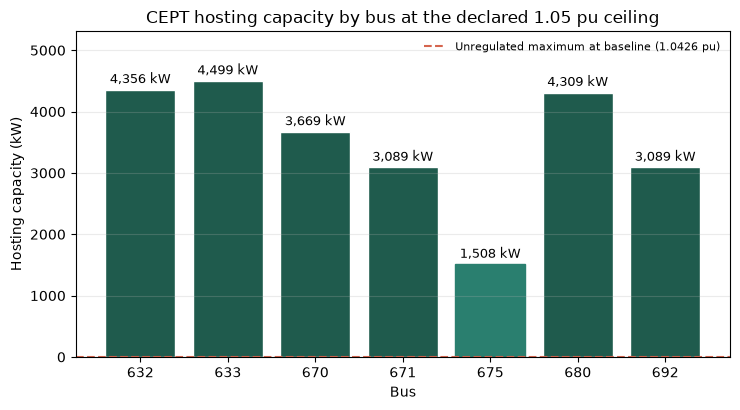

In [6]:
#@title 6. Plot — hosting capacity by bus against the declared ceiling
import matplotlib.pyplot as plt

_hc = read(WORKSPACE / "runs" / "03-hosting-capacity" / "results.json")["hosting_capacity"]
_order = sorted(_hc["items"], key=lambda row: row["bus"])
buses = [row["bus"] for row in _order]
capacities = [float(row["hc_kw"]) for row in _order]
hc_kw = float(next(row for row in _order if row["bus"].lower() == "675")["hc_kw"])
baseline_v_max = float(_hc["baseline_v_max_pu"])

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(buses, capacities, color="#1f5b4d", edgecolor="white")
bars[buses.index("675")].set_color("#2a7f6f")
ax.axhline(baseline_v_max, color="#d5654e", linestyle="--", linewidth=1.5,
           label=f"Unregulated maximum at baseline ({baseline_v_max:.4f} pu)")
for bar, value in zip(bars, capacities):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 60, f"{value:,.0f} kW",
            ha="center", va="bottom", fontsize=9)
ax.set_title(f"CEPT hosting capacity by bus at the declared {V_MAX_PU:.2f} pu ceiling")
ax.set_xlabel("Bus")
ax.set_ylabel("Hosting capacity (kW)")
ax.set_ylim(0, max(capacities) * 1.18)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)


## ✓ Verify — Check the saved run

Verify this exact run directory and its persisted artifacts.


In [7]:
# 6. Verify — check this exact saved run
!cept verify runs/03-hosting-capacity --format text

CEPT study check: PASSED
----------------------------
Study              Hosting capacity (OpenDSS)
Case fingerprint   849d2148e0b1 (matches the case you ran)

Checked   3 groups, 13 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (2 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json


## ◇ Interpret — Bound the result

- The returned `hc_kw` is specific to this feeder model and the one declared criterion.
- It does not establish utility approval, thermal adequacy, protection adequacy, or project validation.

**Try next:** alter the declared criterion or an explicit assumption, then treat the result as a new question.

## 🧪 Optional — Compare a direct OpenDSS bracket

These cells solve 0, 1000, and 2000 kW directly, then compare that bracket with the persisted CEPT result.

In [8]:
#@title Under the hood - direct OpenDSS sweep (optional)
MASTER_DSS = ieee13_master()
import opendssdirect as dss

def load_base():
    dss.Basic.ClearAll()
    dss.Basic.DataPath(str(MASTER_DSS.parent))
    dss.Text.Command(f'Redirect "{MASTER_DSS}"')
    dss.Text.Command('CalcVoltageBases')
    dss.Text.Command('Solve')
    assert dss.Solution.Converged()

def max_unregulated_voltage():
    excluded = {'sourcebus', '650', 'rg60'}
    names = dss.Circuit.AllNodeNames()
    values = dss.Circuit.AllBusMagPu()
    return max(value for name, value in zip(names, values) if name.split('.')[0].lower() not in excluded)

direct_sweep = {}
for kw in DIRECT_SIZES_KW:
    load_base()
    dss.Text.Command(f'New PVSystem.lesson_pv phases=3 bus1=675.1.2.3 kV=4.16 kVA={max(kw, 1)} Pmpp={kw} irradiance=1 pf=1 %cutin=0.05 %cutout=0.05')
    dss.Text.Command('Solve')
    assert dss.Solution.Converged()
    direct_sweep[kw] = max_unregulated_voltage()
os.chdir(WORKSPACE)
print(f"Direct OpenDSS sweep finished: solved {len(direct_sweep)} PV sizes.")


Direct OpenDSS sweep finished: solved 3 PV sizes.


In [9]:
#@title Under the hood — direct sweep readback (optional)
table(['PV size', 'maximum unregulated voltage', 'unit'], [(kw, value, 'pu') for kw, value in direct_sweep.items()])
assert direct_sweep[1000] < V_MAX_PU < direct_sweep[2000]

PV size  maximum unregulated voltage  unit
-------  ---------------------------  ----
0        1.0426313303211827           pu
1000     1.0476066810380371           pu
2000     1.0521988003106502           pu


In [10]:
#@title Compare solver outputs (optional details)
RUN_DIR = WORKSPACE / "runs" / "03-hosting-capacity"
results = read(RUN_DIR / "results.json")
verify_summary = read(RUN_DIR / "public-verification.json")
hosting = results["hosting_capacity"]
item = next(row for row in hosting["items"] if row["bus"].lower() == "675")
table(
    ["field", "value", "unit"],
    [
        ("criterion", hosting["criterion"], "text"),
        ("v_max", hosting["v_max_pu"], "pu"),
        ("baseline_v_max", hosting["baseline_v_max_pu"], "pu"),
        ("bus 675 capacity", item["hc_kw"], "kW"),
        ("bus 675 limit", item["limit"], "text"),
    ],
)
print()
print("CEPT hosting-capacity result")
print("----------------------------")
print(f"Result        {'PASSED' if verify_summary['passed'] else 'Needs attention'}")
print(f"Bus 675 can host about {item['hc_kw']} kW before hitting the voltage limit")
print(f"Limit reached: {item['limit']}")
assert verify_summary["status"] == "PASS"
assert verify_summary["passed"] is True
assert abs(direct_sweep[0] - hosting["baseline_v_max_pu"]) < 1e-3
assert 1000 <= item["hc_kw"] <= 2000
assert hosting["criterion"] == "overvoltage" and hosting["v_max_pu"] == V_MAX_PU


field             value        unit
----------------  -----------  ----
criterion         overvoltage  text
v_max             1.05         pu
baseline_v_max    1.0426       pu
bus 675 capacity  1507.6       kW
bus 675 limit     overvoltage  text

CEPT hosting-capacity result
----------------------------
Result        PASSED
Bus 675 can host about 1507.6 kW before hitting the voltage limit
Limit reached: overvoltage
